In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import seaborn as sns
sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 12))

https://www.statsmodels.org/dev/examples/notebooks/generated/mstl_decomposition.html

In [8]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


In [9]:
train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'

In [10]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 112651 entries, 2010-07-02 12:00:00 to 2016-12-04 09:00:00
Freq: 30min
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TOTALDEMAND        112651 non-null  float64
 1   demand_1_day_ago   112651 non-null  float64
 2   demand_1_week_ago  112651 non-null  float64
 3   demand_1_year_ago  112651 non-null  float64
 4   TEMPERATURE        112651 non-null  float64
 5   RMSE_48            112651 non-null  float64
 6   TSE_48             112651 non-null  float64
dtypes: float64(7)
memory usage: 6.9 MB


<Figure size 1600x1200 with 0 Axes>

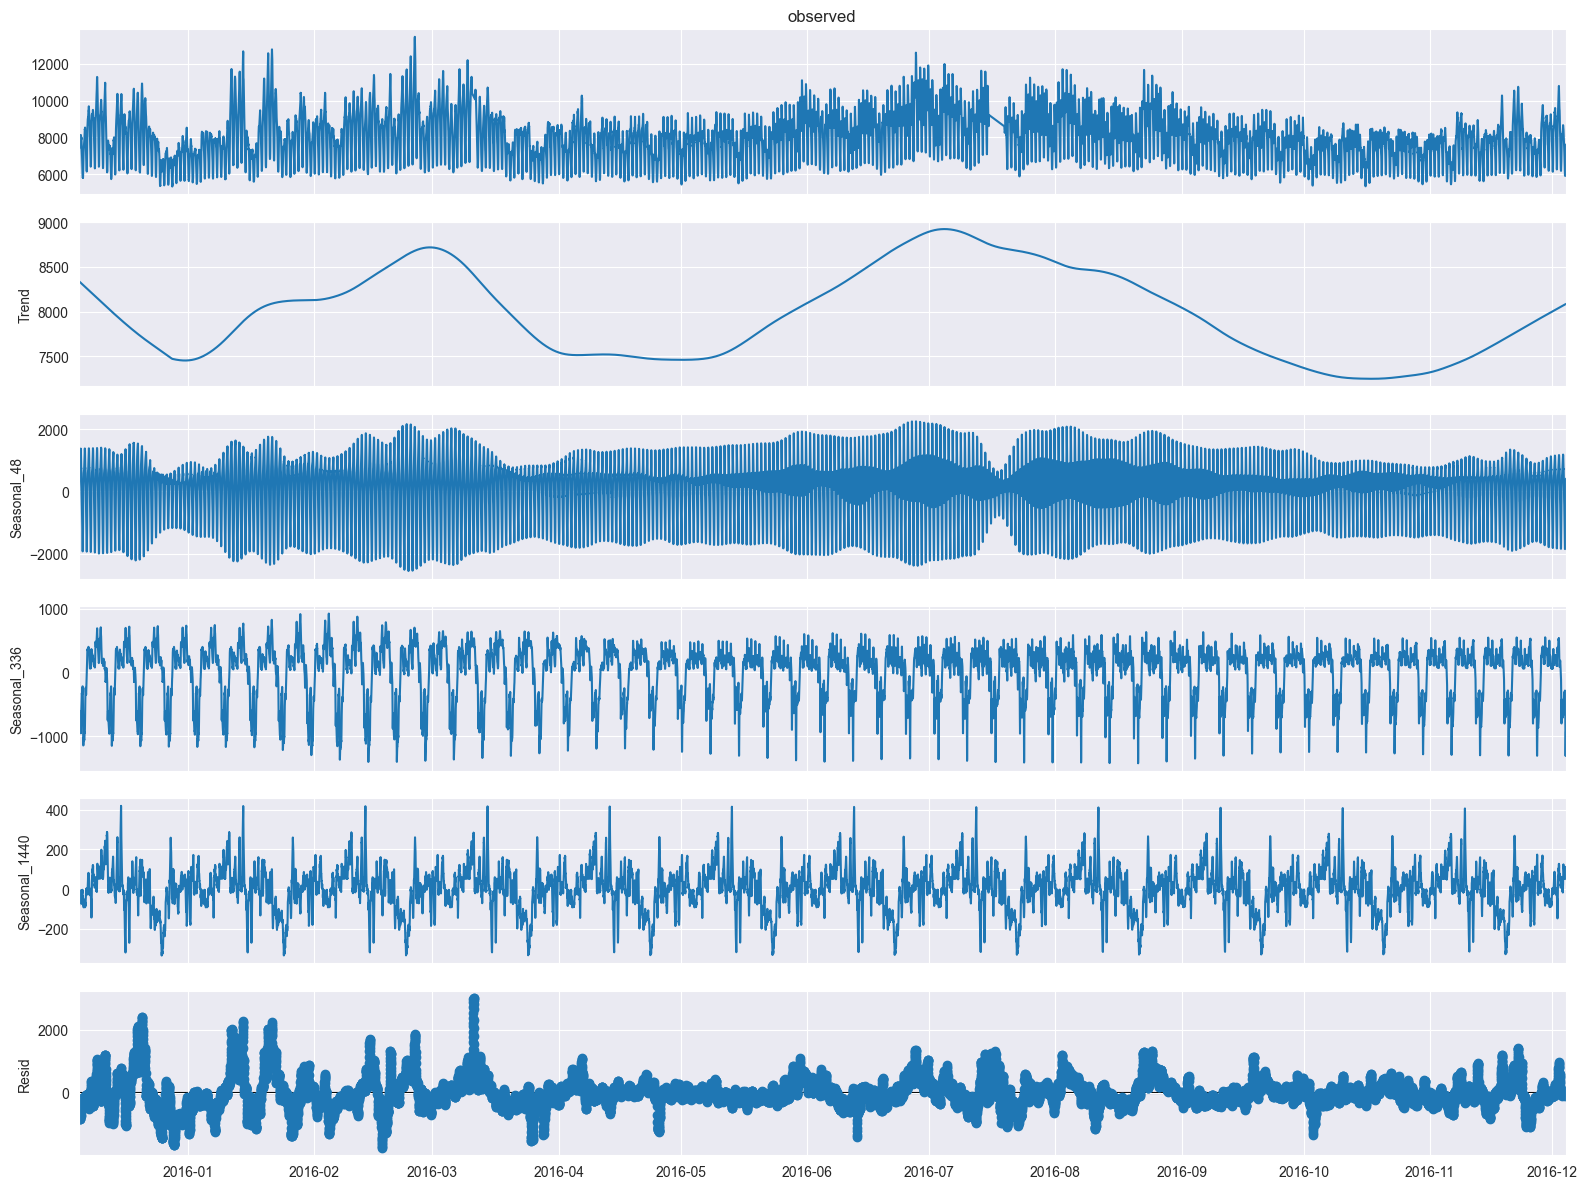

In [45]:
lookback_window = 17532
subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]


stl = MSTL(
    subset_train['TOTALDEMAND'], 
    windows=(11, 15, 19*4-1),
    periods=(48, 336, 48*30),
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
res = stl.fit()
plt.figure(figsize=(16,12))
fig = res.plot()
plt.show()

In [40]:
res.trend

DATETIME
2015-12-05 03:00:00    8251.485401
2015-12-05 03:30:00    8250.716924
2015-12-05 04:00:00    8249.948485
2015-12-05 04:30:00    8249.180084
2015-12-05 05:00:00    8248.411721
                          ...     
2016-12-04 07:00:00    8022.792250
2016-12-04 07:30:00    8023.247944
2016-12-04 08:00:00    8023.703622
2016-12-04 08:30:00    8024.159282
2016-12-04 09:00:00    8024.614925
Freq: 30min, Name: trend, Length: 17533, dtype: float64

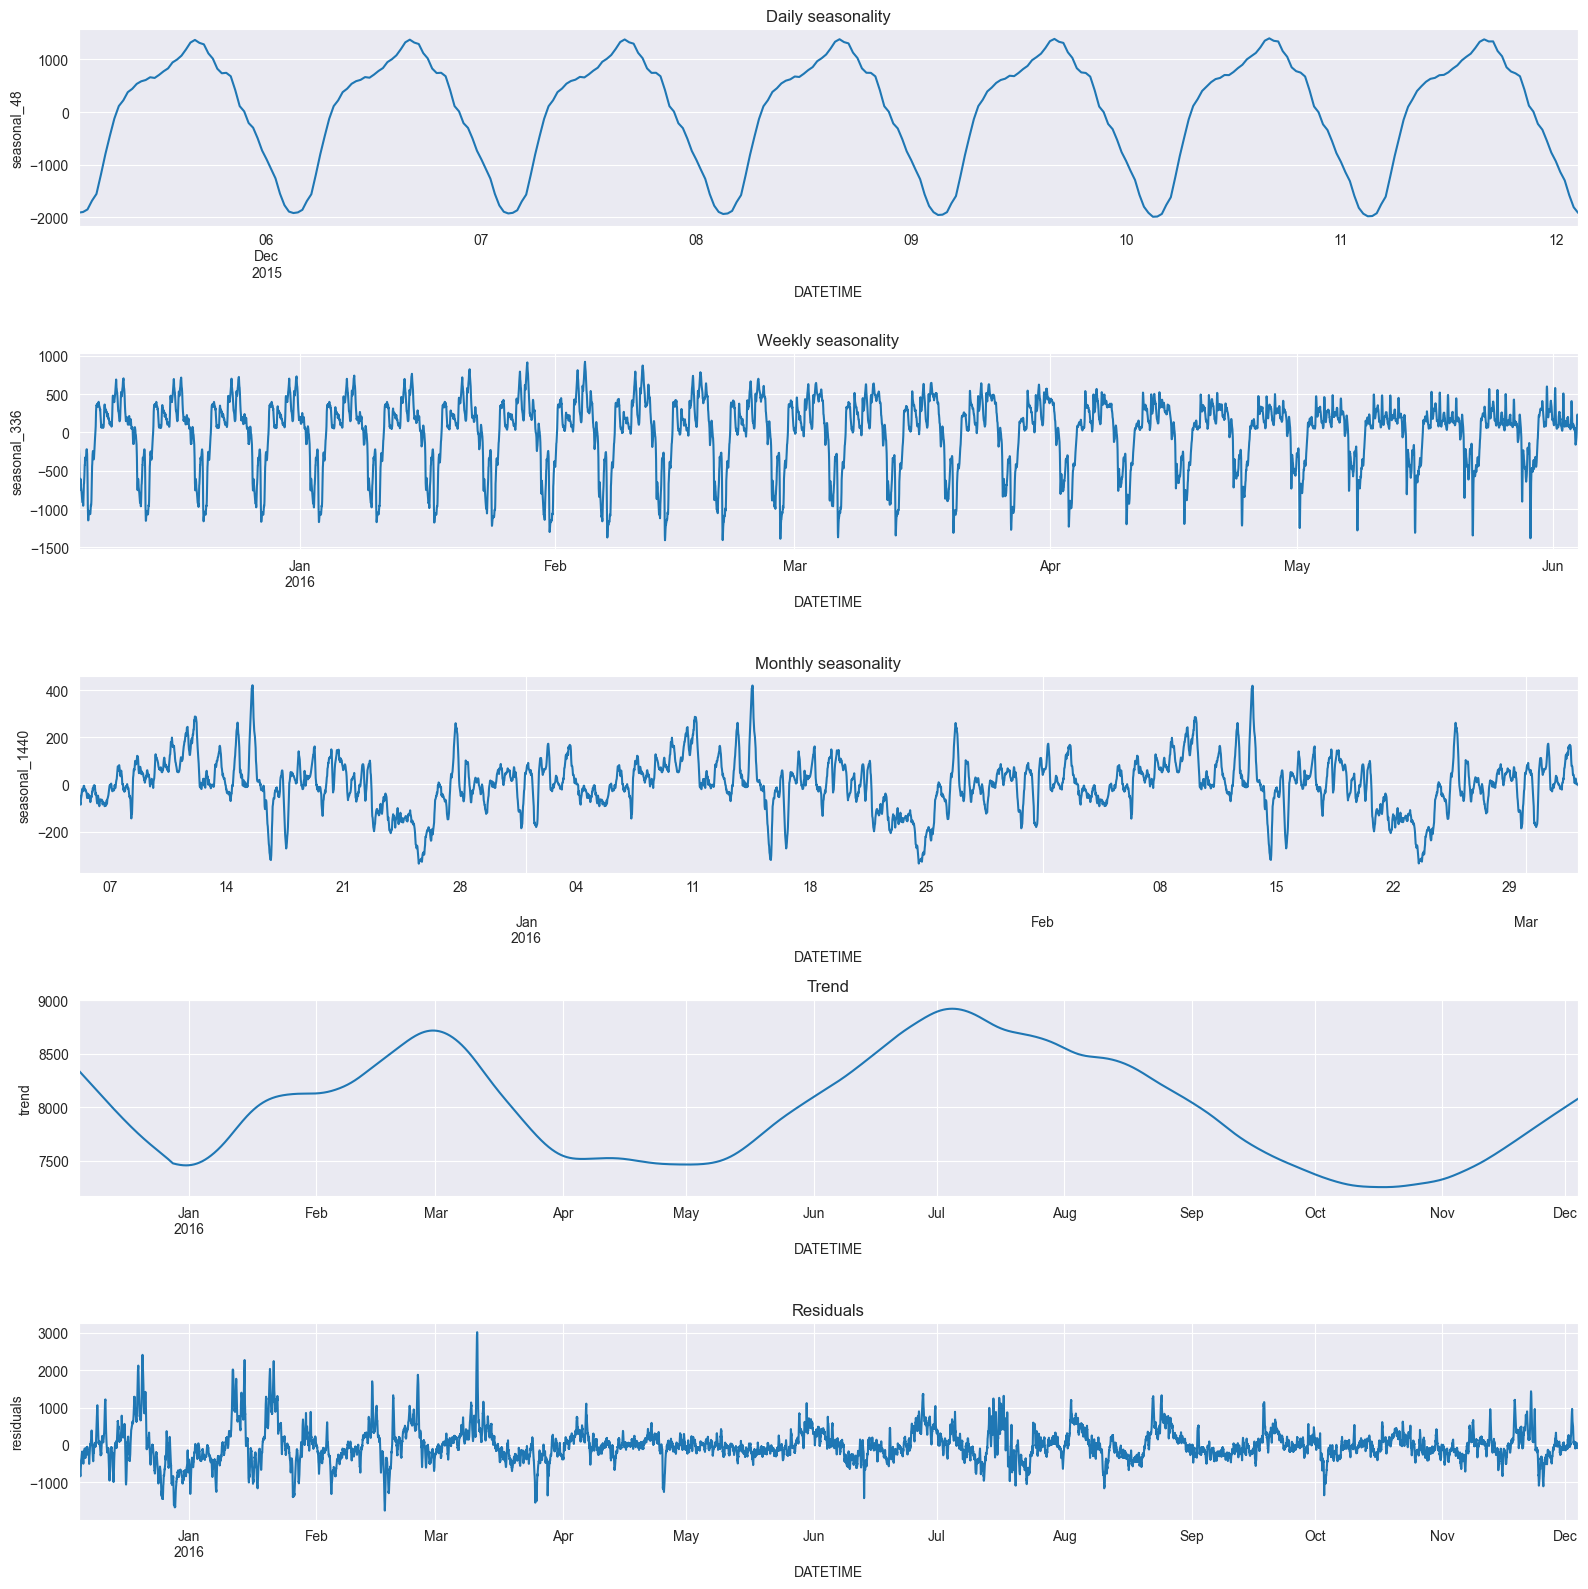

In [48]:
fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
res.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_48")
ax[0].set_title("Daily seasonality")

res.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_336")
ax[1].set_title("Weekly seasonality")

res.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_1440")
ax[2].set_title("Monthly seasonality")

res.trend.iloc[: 48 * 365].plot(ax=ax[3])
ax[3].set_ylabel("trend")
ax[3].set_title("Trend")

res.resid.iloc[: 48 * 365].plot(ax=ax[4])
ax[4].set_ylabel("residuals")
ax[4].set_title("Residuals")

plt.tight_layout()

https://otexts.com/fpp3/